# Cook Data Exploration

## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications import vgg16

## Data Import and Combine

### Crop

In [2]:
crop = pd.read_csv("./Data/CookHandHarvest_HY1999-HY2016_P3A3_20241029(in).csv")

In [3]:
shape_before = crop.shape
print(shape_before)

(6642, 26)


In [4]:
# drop any columns that are more than 1000 missing values
crop = crop.loc[:, crop.isna().sum() <= 1000]

# Drop unnecessary "SampleID" Column
crop.drop(columns=["SampleID"], inplace=True)

In [5]:
# Drop rows with missing "Crop" or "GrainYieldAirDry" Values
crop = crop.dropna()
crop.isna().sum()

HarvestYear         0
ID2                 0
Longitude           0
Latitude            0
Crop                0
QCCoverage          0
QCFlags             0
CropExists          0
GrainYieldAirDry    0
dtype: int64

In [6]:
shape_after = crop.shape
print(shape_after) 

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(6285, 9)
Dropped Column amount: 17
Dropped Row amount: 357


### Terrain

In [7]:
terrain = pd.read_csv("./Data/CookTerrainAttributes10m2_P3A1_20210119.csv")

In [8]:
terrain.head()

,ID2,FieldName,Latitude,Longitude,Elevation,AnalyticalHillshade,ConvergenceIndex,TotalCatchmentArea,TopographicWetnessIndex,LengthSlopeFactor,...,ChannelNetworkDistance,ValleyDepth,RelativeSlopePosition,Slope,Aspect,TRASP,ProfileCurvature,PlanCurvature,TangentialCurvature,AnnualGlobalSolarRadiation
0,1,CookEast,46.778729,-117.087514,781.48643,0.857087,3.197987,682.413452,5.702310,1.407364,...,2.433228,31.977112,0.070712,7.600873,195.363983,0.983775,-0.000807,-0.001175,-0.000155,1860.944336
1,2,CookEast,46.778692,-117.087065,782.43932,0.835344,-0.196646,1105.528442,6.433780,1.126312,...,2.692078,31.024231,0.079845,5.939017,198.724243,0.990349,-0.001025,-0.004596,-0.000476,1833.973389
2,3,CookEast,46.778791,-117.086678,784.93625,0.859389,1.008778,689.028320,5.602043,1.622139,...,4.639526,28.526917,0.139886,8.471982,198.494370,0.989953,-0.001278,0.009172,0.001351,1871.270264
3,4,CookEast,46.778761,-117.086260,786.42902,0.876073,-0.155071,865.019226,5.865278,1.622096,...,5.796997,27.032532,0.176579,8.178418,188.564774,0.965416,-0.000061,0.024965,0.003551,1873.524658
4,5,CookEast,46.778666,-117.085842,786.51237,0.843491,0.770311,563.946228,5.538609,1.308802,...,5.668457,26.945679,0.173804,7.400980,201.473892,0.994474,-0.001019,0.025449,0.003278,1853.676514


In [9]:
shape_before = terrain.shape
print(shape_before)

(619, 21)


In [10]:
terrain.isna().sum()

ID2                           0
FieldName                     0
Latitude                      0
Longitude                     0
Elevation                     0
AnalyticalHillshade           0
ConvergenceIndex              0
TotalCatchmentArea            0
TopographicWetnessIndex       0
LengthSlopeFactor             0
ChannelNetworkBaseLevel       0
ChannelNetworkDistance        0
ValleyDepth                   0
RelativeSlopePosition         0
Slope                         0
Aspect                        0
TRASP                         0
ProfileCurvature              0
PlanCurvature                 0
TangentialCurvature           0
AnnualGlobalSolarRadiation    0
dtype: int64

In [11]:
shape_after = terrain.shape
print(shape_after) 

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(619, 21)
Dropped Column amount: 0
Dropped Row amount: 0


### Combine

In [12]:
print(f"crop['ID2'].nunique(): {crop['ID2'].nunique()}")
print(f"terrain['ID2'].nunique(): {terrain['ID2'].nunique()}")

crop['ID2'].nunique(): 369
terrain['ID2'].nunique(): 619


`crop` only contains data from *Cook East* location but `terrain` contains data from *Cook East* and *Cook West*

In [13]:
print(f"terrain['Longitude'].iloc[0]: {terrain['Longitude'].iloc[0]}")
print(f"crop['Longitude'].iloc[0]: {crop['Longitude'].iloc[0]}")

terrain['Longitude'].iloc[0]: -117.08751399999728
crop['Longitude'].iloc[0]: -117.087514


In [14]:
# Combine "crop" and "terrain" dataframes on "ID2" column
combined = pd.merge(crop, terrain, on=["ID2"], how="inner")

**Note:** I tried to merge based off Longitude and Latitude but the "terrain" dataframes values are more precise so the values do not match (see cell above). This is why we merge based on "ID2" primarily. Later we should return to this and ensure that the ID2's Longitude and Latitude match. 

In [15]:
combined.shape

(6285, 29)

In [16]:
combined.isna().sum()

HarvestYear                   0
ID2                           0
Longitude_x                   0
Latitude_x                    0
Crop                          0
QCCoverage                    0
QCFlags                       0
CropExists                    0
GrainYieldAirDry              0
FieldName                     0
Latitude_y                    0
Longitude_y                   0
Elevation                     0
AnalyticalHillshade           0
ConvergenceIndex              0
TotalCatchmentArea            0
TopographicWetnessIndex       0
LengthSlopeFactor             0
ChannelNetworkBaseLevel       0
ChannelNetworkDistance        0
ValleyDepth                   0
RelativeSlopePosition         0
Slope                         0
Aspect                        0
TRASP                         0
ProfileCurvature              0
PlanCurvature                 0
TangentialCurvature           0
AnnualGlobalSolarRadiation    0
dtype: int64

## Data Exploration

In [17]:
# Drop "QCCoverage" column becauuse it is NaN

combined.drop(columns=["QCCoverage"], inplace=True)

In [18]:
# Remove the following to simplify the dataset
columns_to_remove = [
    "ID2",
    "HarvestYear",
    "Longitude_x",
    "Latitude_x",
    "Longitude_y",
    "Latitude_y",
    "FieldName",
    
]
combined.drop(columns=columns_to_remove, inplace=True)

In [19]:
print(combined.columns.tolist())

['Crop', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


In [20]:
combined.shape

(6285, 21)

In [21]:
combined["GrainYieldAirDry"].max()

883.2212021

In [ ]:
combined["GrainYieldAirDry"].min()

0.0

In [ ]:
print(combined.columns.tolist())

['Crop', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


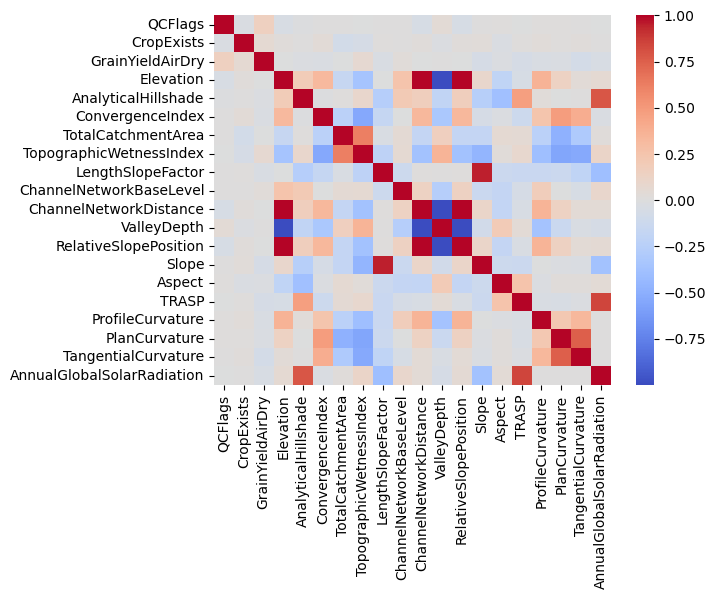

In [25]:
corr = combined.select_dtypes(include="number").corr()

sns.heatmap(corr, cmap="coolwarm")
plt.show()


## Data Processing

### Encoding Categorical Values

In [ ]:
print(combined.select_dtypes(include=["object", "category"]).columns.tolist())


['Crop']


In [30]:
le = LabelEncoder()
combined["Crop"] = le.fit_transform(combined["Crop"].astype(str))


In [31]:
combined["Crop"].value_counts()

Crop
10    1981
4     1905
1      650
0      614
2      601
3      189
5      109
8       92
7       61
9       48
6       35
Name: count, dtype: int64

In [32]:
print(combined.select_dtypes(include=["object", "category"]).columns.tolist())

[]


### Split

In [34]:
target_column = "GrainYieldAirDry"

X = combined.drop(columns=[target_column])
y = combined[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

## Model

X_train, X_test, y_train, y_test 

In [39]:
print(f'X_train.shape: {X_train.shape}')
print(f'X_train.shape: {X_test.shape}')
print(f'X_train.shape: {y_train.shape}')
print(f'X_train.shape: {y_test.shape}')

X_train.shape: (5028, 20)
X_train.shape: (1257, 20)
X_train.shape: (5028,)
X_train.shape: (1257,)


In [ ]:
# Your Code Here
inputs = Input(shape=(128, 128, 3))
conv1a = Conv2D(filters=64, kernel_size=3, padding='same')(inputs)
conv1b = Conv2D(filters=64, kernel_size=3, padding='same')(conv1a)
pool1 = MaxPooling2D()(conv1b)
conv2a = Conv2D(filters=128, kernel_size=3, padding='same')(pool1)
conv2b = Conv2D(filters=128, kernel_size=3, padding='same')(conv2a)
pool2 = MaxPooling2D()(conv2b)
conv3a = Conv2D(filters=256, kernel_size=3, padding='same')(pool2)
conv3b = Conv2D(filters=256, kernel_size=3, padding='same')(conv3a)
pool3 = MaxPooling2D()(conv3b)
flat = Flatten()(pool3)
dense1 = Dense(128, activation='relu')(flat)
dense2 = Dense(64, activation='relu')(dense1)
outputs = Dense(10, activation='softmax')(dense2)

model_1 = Model(inputs, outputs)